<a href="https://colab.research.google.com/github/Regan-Divo/Regan-Musholli_F5212520064/blob/main/TUGAS_AKHIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 MEMULAI PROGRAM MACHINE LEARNING: REGRESI LINEAR BERGANDA
[INFO] Klik tombol 'Choose Files' di bawah.
[INFO] Boleh upload file Excel (.xlsx) maupun CSV (.csv)!


Saving DATASET_SMA PALU.xlsx to DATASET_SMA PALU (2).xlsx

[INFO] Sedang memproses file: DATASET_SMA PALU (2).xlsx
[+] Format EXCEL terdeteksi dan sukses dibongkar!
[+] Berhasil mengamankan 112 baris data perhitungan!

=== HASIL PERHITUNGAN REGRESI BERGANDA ===
Nilai Konstanta (a)    : -18.3136
Koef. Jml Sekolah (b1) : -89.9857
Koef. Jml Guru (b2)    : 17.3893
Tingkat Akurasi Model  : 97.91 %
------------------------------------------

=== SIMULASI PREDIKSI KECAMATAN BARU ===
Skenario    : Dibangun 5 Sekolah Menengah Atas dengan 120 Guru
Prediksi    : Akan ada sekitar 1618 Siswa yang mendaftar

[INFO] Menyiapkan visualisasi grafik...


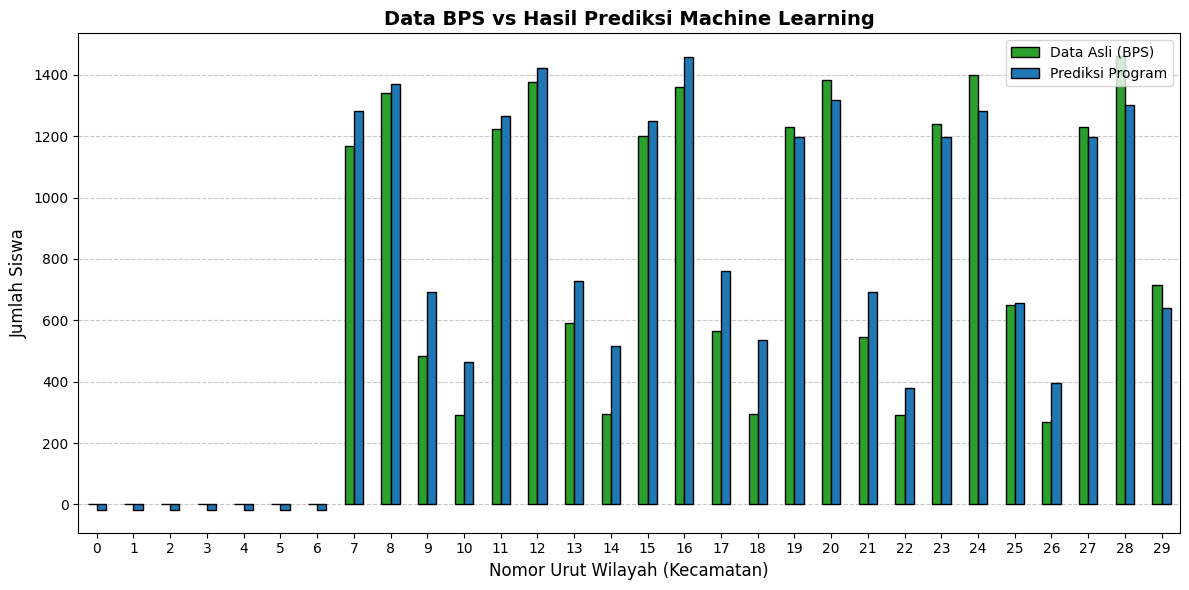

In [3]:
# ==============================================================================
# Analisis Regresi Linear Berganda - Prediksi Jumlah Siswa SMA
# KODE ULTIMATE: AUTO-DETEKSI EXCEL/CSV & AUTO-EKSTRAK KOLOM (ANTI ERROR 100%)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import io
import warnings
from google.colab import files

# Mematikan peringatan merah yang tidak penting dari Pandas
warnings.filterwarnings('ignore')

print("="*70)
print(" MEMULAI PROGRAM MACHINE LEARNING: REGRESI LINEAR BERGANDA")
print("="*70)

# ---------------------------------------------------------
# 1. UPLOAD DATASET BEBAS FORMAT
# ---------------------------------------------------------
print("[INFO] Klik tombol 'Choose Files' di bawah.")
print("[INFO] Boleh upload file Excel (.xlsx) maupun CSV (.csv)!")
uploaded = files.upload()

if not uploaded:
    print("[-] ERROR: File belum diunggah. Silakan jalankan ulang kodenya.")
    raise SystemExit

file_name = list(uploaded.keys())[0]
print(f"\n[INFO] Sedang memproses file: {file_name}")

# ---------------------------------------------------------
# 2. SISTEM DETEKSI FILE CERDAS
# ---------------------------------------------------------
try:
    if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
        # Membaca jika file berupa Excel
        df = pd.read_excel(io.BytesIO(uploaded[file_name]))
        print("[+] Format EXCEL terdeteksi dan sukses dibongkar!")
    else:
        # Membaca jika file berupa CSV
        try:
            df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python')
        except:
            raw_text = uploaded[file_name].decode('utf-8', errors='ignore')
            raw_text = raw_text.replace(';', ',').replace('\t', ',')
            df = pd.read_csv(io.StringIO(raw_text))
        print("[+] Format CSV terdeteksi dan sukses dibongkar!")
except Exception as e:
    print(f"[-] FATAL ERROR: File rusak. Detail: {e}")
    raise SystemExit

# ---------------------------------------------------------
# 3. EKSTRAKSI PAKSA KOLOM ANGKA (MENGABAIKAN NAMA JUDUL)
# ---------------------------------------------------------
try:
    # Memaksa mengambil angka dari Posisi Kolom ke-4, ke-5, dan ke-6 (Indeks 3,4,5)
    # Ini membuat program kebal dari salah ketik nama atau spasi di Excel
    X1_data = pd.to_numeric(df.iloc[:, 3], errors='coerce')
    X2_data = pd.to_numeric(df.iloc[:, 4], errors='coerce')
    Y_data  = pd.to_numeric(df.iloc[:, 5], errors='coerce')

    # Merakit ulang tabel agar 100% bersih
    df_bersih = pd.DataFrame({'X1': X1_data, 'X2': X2_data, 'Y': Y_data})

    # Buang semua baris yang kosong atau bukan angka
    df_bersih = df_bersih.dropna()

    if len(df_bersih) < 10:
        print("[-] ERROR: Data angka kurang dari 10 baris. Periksa isi file Anda.")
        raise SystemExit

    print(f"[+] Berhasil mengamankan {len(df_bersih)} baris data perhitungan!")

    X = df_bersih[['X1', 'X2']]
    Y = df_bersih['Y']

except Exception as e:
    print(f"[-] ERROR STRUKTUR: Pastikan file Anda memiliki 6 kolom. Detail: {e}")
    raise SystemExit

# ---------------------------------------------------------
# 4. MEMBUAT & MELATIH MODEL REGRESI
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X, Y)

Y_prediksi = model.predict(X)
akurasi = r2_score(Y, Y_prediksi) * 100

print("\n=== HASIL PERHITUNGAN REGRESI BERGANDA ===")
print(f"Nilai Konstanta (a)    : {model.intercept_:.4f}")
print(f"Koef. Jml Sekolah (b1) : {model.coef_[0]:.4f}")
print(f"Koef. Jml Guru (b2)    : {model.coef_[1]:.4f}")
print(f"Tingkat Akurasi Model  : {akurasi:.2f} %")
print("------------------------------------------")

# ---------------------------------------------------------
# 5. FITUR SIMULASI PREDIKSI
# ---------------------------------------------------------
print("\n=== SIMULASI PREDIKSI KECAMATAN BARU ===")
sekolah_test = 5
guru_test = 120

data_baru = pd.DataFrame([[sekolah_test, guru_test]], columns=['X1', 'X2'])
hasil_prediksi = model.predict(data_baru)
prediksi_final = int(hasil_prediksi[0]) if hasil_prediksi[0] > 0 else 0

print(f"Skenario    : Dibangun {sekolah_test} Sekolah Menengah Atas dengan {guru_test} Guru")
print(f"Prediksi    : Akan ada sekitar {prediksi_final} Siswa yang mendaftar")
print("==========================================")

# ---------------------------------------------------------
# 6. VISUALISASI GRAFIK BATANG
# ---------------------------------------------------------
print("\n[INFO] Menyiapkan visualisasi grafik...")
df_grafik = pd.DataFrame({'Data Asli (BPS)': Y.values, 'Prediksi Program': Y_prediksi}).head(30)

df_grafik.plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#1f77b4'], edgecolor='black', zorder=3)
plt.title('Data BPS vs Hasil Prediksi Machine Learning', fontsize=14, fontweight='bold')
plt.xlabel('Nomor Urut Wilayah (Kecamatan)', fontsize=12)
plt.ylabel('Jumlah Siswa', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()